In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd())) 

from llm_provider import LLM_provider
llm=LLM_provider()
model=llm.get_llm()
model.invoke("hi")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 8, 'total_tokens': 18, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 6, 'engine_ttft_ms': 35, 'engine_ttlt_ms': 93, 'pre_inference_ms': 90, 'service_tbt_ms': 6, 'service_ttft_ms': 788, 'service_ttlt_ms': 845, 'total_duration_ms': 759, 'user_visible_ttft_ms': 698}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_7a7fd0eb44', 'id': 'chatcmpl-DfgafJZ2Xx8H4129fsTZxp940CVCa', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {

<!-- User: "What's the weather in Paris?"

Round 1:
  agent_node → LLM says "I need to search" 
  → AIMessage(tool_calls=[search("Paris weather")])
  → should_continue → tool_calls not empty → "tools"

Round 2:
  tool_node → runs search → adds ToolMessage("22°C sunny")
  → back to agent_node → LLM now has the result
  → AIMessage("The weather in Paris is 22°C")
  → should_continue → tool_calls empty → END -->


In [8]:
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import MessagesState,END,START,StateGraph

## ReAct Agent — The Big Picture

**ReAct = Reason + Act**. A single LLM in a loop asking itself: "Do I need a tool or can I answer now?"

```
User asks question
      ↓
agent_node → LLM decides:
      ↓                  ↓
"I need a tool"      "I know the answer"
      ↓                  ↓
tool_node runs       END — done
      ↓
result added to messages
      ↓
back to agent_node → LLM decides again
```

**Import buckets:**
- `langgraph.graph` → graph stuff (StateGraph, MessagesState, START, END)
- `langgraph.prebuilt` → shortcuts (ToolNode, create_react_agent)
- `langchain_community.tools` → third party tools (DuckDuckGo, etc.)

In [3]:
search=DuckDuckGoSearchRun()
tools=[search]
model_with_tools=model.bind_tools(tools)

## Note: bind_tools

`model.bind_tools(tools)` tells the LLM what tools are available. It sends the tool schemas to the LLM so it knows:
- What tools exist
- What arguments each tool takes
- When to use them

Without `bind_tools`, the LLM has no idea tools exist and will never call them.

In [12]:
def agent_node(state:MessagesState):
    result=model_with_tools.invoke(state["messages"])
    return {"messages":[result]}

## Note: agent_node

Sends all messages to the LLM and gets one AIMessage back. No prompt template needed — `bind_tools` already told the LLM about the tools.

The LLM returns either:
- `AIMessage(tool_calls=[...])` → it wants to call a tool → `finish_reason: "tool_calls"`
- `AIMessage(content="...")` → it has the final answer → `finish_reason: "stop"`

**Why `return {"messages": [result]}`?**
- Key must match the state field name → `"messages"`
- Wrapped in a list because `add_messages` reducer expects a list
- `add_messages` APPENDS it to existing messages, doesn't overwrite

In [13]:
from langgraph.prebuilt import ToolNode

In [14]:
tool_node = ToolNode(tools)

In [15]:
# from langchain_core.messages import ToolMessage
# def tool_node(state:MessagesState):
#     last_message=state["messages"][-1]
#     tool_call=last_message.tool_calls[0]
#     result=search.invoke(tool_call["args"])
#     return {"messages": [ToolMessage(content=result, tool_call_id=tool_call["id"])]}

## Note: ToolNode (prebuilt) vs Manual tool_node

**Prebuilt `ToolNode(tools)`** — handles everything automatically:
- Reads `messages[-1]` (the AIMessage with tool_calls)
- Matches tool name → runs the right tool
- Wraps result in `ToolMessage` with correct `tool_call_id`
- Handles multiple tool calls at once

**Manual version** — same thing but only handles one tool call `[0]`:
```
messages[-1]                    → AIMessage with tool_calls list
tool_calls[0]                   → one dict: {"id": "...", "name": "...", "args": {...}}
tool_calls[0]["args"]           → the actual input to pass to the tool
ToolMessage(tool_call_id=...)   → result wrapped with matching ID so LLM knows which call it answers
```

**`tool_call_id`** is required — LLM needs to match the result back to which tool call it made.

Use prebuilt in production, manual for understanding what's happening.

In [16]:
def should_continue(state:MessagesState):
    last_message=state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END

## Note: should_continue — the router that makes it a loop

This is what makes ReAct a **loop** instead of a straight line.

After every `agent_node` run, LangGraph calls this function:
- `messages[-1]` = the AIMessage the LLM just returned
- `tool_calls` is a list — if not empty, LLM wants a tool
- If empty, LLM is done → END

```
messages[-1].tool_calls = [{"name": "search", ...}]  → "tools" → keep looping
messages[-1].tool_calls = []                          → END     → stop
```

**`messages[-1]` always = "what just happened"** — the most recent message added to state.

In [23]:
graph=StateGraph(MessagesState)

In [24]:
graph.add_node("agent",agent_node)
graph.add_node("tools", tool_node)



In [25]:
graph.add_edge(START,"agent")
graph.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
graph.add_edge("tools", "agent")

## Note: The 3 edges

```python
graph.add_edge(START, "agent")
# FIXED: always start at agent. No choice.

graph.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
# DYNAMIC: after agent runs → call should_continue → route based on return value
# dict maps: return value → node name (both happen to be "tools" here, but they can differ)

graph.add_edge("tools", "agent")
# FIXED: after tools runs → always go back to agent. No choice.
# Because LLM needs to READ the tool result and decide what to do next.
```

The loop:  START → agent → tools → agent → tools → agent → END

In [26]:
app=graph.compile()

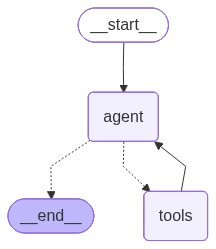

In [27]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [30]:
from langchain_core.messages import HumanMessage

result = app.invoke({"messages": [HumanMessage("What is the latest news about AI?")]})
result


{'messages': [HumanMessage(content='What is the latest news about AI?', additional_kwargs={}, response_metadata={}, id='e563fd34-2a05-456b-a863-426ab28921c6'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 81, 'total_tokens': 102, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 4, 'engine_ttft_ms': 26, 'engine_ttlt_ms': 112, 'pre_inference_ms': 85, 'service_tbt_ms': 7, 'service_ttft_ms': 449, 'service_ttlt_ms': 593, 'total_duration_ms': 504, 'user_visible_ttft_ms': 364}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_7a7fd0eb44', 'id': 'chatcmpl-DflBwnfShclcqIaT0auGlqufhhyst', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_index': 0, 'content_f

In [32]:
from langchain_core.messages import HumanMessage

result = app.invoke({"messages": [HumanMessage("What is the latest news about AI?")]})
result


{'messages': [HumanMessage(content='What is the latest news about AI?', additional_kwargs={}, response_metadata={}, id='c3c6e296-168a-43ea-b4f2-b6c334027f51'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 81, 'total_tokens': 102, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 7, 'engine_ttft_ms': 57, 'engine_ttlt_ms': 196, 'pre_inference_ms': 96, 'service_tbt_ms': 7, 'service_ttft_ms': 611, 'service_ttlt_ms': 748, 'total_duration_ms': 662, 'user_visible_ttft_ms': 515}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_f84d8a14a9', 'id': 'chatcmpl-DixR3HUidzKqqx8S4mDPRgQIEfFNC', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_index': 0, 'content_f